# Prediction-success evaluation — multi-algorithm sweep

This notebook runs a full **prediction of success evaluation** for the preflop
hero-action classifier and compares five algorithm families on identical
features/splits:

| id | model | source |
|----|-------|--------|
| `logistic`     | Multinomial logistic regression (baseline)    | `sklearn.linear_model` |
| `random_forest`| Random forest (400 trees)                     | `sklearn.ensemble` |
| `hist_gbm`     | Histogram gradient boosting                   | `sklearn.ensemble` |
| `lightgbm`     | LightGBM multiclass (project baseline)        | `lightgbm` |
| `xgboost`      | XGBoost multi:softprob                        | `xgboost` |

For each model we report:

- **accuracy / macro-F1 / weighted-F1** on the 1k PokerBench preflop test split.
- **log loss** (proxy for KL divergence from the solver's mixed strategy).
- **top-2 accuracy** (does the true action land in the model's top 2 picks?).
- **per-class precision / recall / F1**.
- **fit time** and **inference time / 1 000 rows**.
- **bluff-EV backtest** using the model's `p(raise)` head vs the shared villain-fold head.

All models are trained on the *same feature matrix* produced by
`poker_predictor.features.build.build_feature_matrix`, so this is a genuine
apples-to-apples comparison of the algorithm, not of the feature pipeline.

In [2]:
from __future__ import annotations

import json
import logging
import os
import sys
import time
import warnings
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'poker_predictor').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
logging.basicConfig(level=logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)

RESULTS_DIR = REPO_ROOT / 'artifacts' / 'prediction_success_eval'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_LIMIT = int(os.environ.get('POKERBENCH_TRAIN_LIMIT', '20000'))
SEED = 7
print(f'repo root       : {REPO_ROOT}')
print(f'train row limit : {TRAIN_LIMIT}')
print(f'results dir     : {RESULTS_DIR}')

repo root       : /Users/morningstar/Desktop/Cold_Storage/Agent_Officespace
train row limit : 20000
results dir     : /Users/morningstar/Desktop/Cold_Storage/Agent_Officespace/artifacts/prediction_success_eval


In [3]:
from poker_predictor.data.loaders import load_pokerbench_preflop
from poker_predictor.features.build import build_feature_matrix, canonical_action_label
from poker_predictor.training.labels import villain_fold_label

def load_split(split: str, limit: int | None = None):
    samples = load_pokerbench_preflop(split=split, limit=limit)
    X_all, raw_y = build_feature_matrix(samples)
    y_canon = [canonical_action_label(v) for v in raw_y]
    mask = [v is not None for v in y_canon]
    X = X_all.loc[mask].reset_index(drop=True)
    y = np.array([v for v in y_canon if v is not None])
    vy = np.array([villain_fold_label(s) for s, m in zip(samples, mask) if m])
    return samples, X, y, vy

print('loading train split ...')
train_samples, X_train, y_train, vy_train = load_split('train', limit=TRAIN_LIMIT)
print(f'  train: {len(X_train)} rows, {X_train.shape[1]} features')

print('loading test split ...')
test_samples, X_test, y_test, vy_test = load_split('test')
print(f'  test : {len(X_test)} rows')

print()
print('train label distribution:')
print(pd.Series(y_train).value_counts(normalize=True).round(4))
print()
print('test label distribution:')
print(pd.Series(y_test).value_counts(normalize=True).round(4))

loading train split ...


/Users/morningstar/Desktop/Cold_Storage/Agent_Officespace/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  train: 20000 rows, 38 features
loading test split ...
  test : 1000 rows

train label distribution:
fold     0.4724
call     0.3968
raise    0.1277
check    0.0032
Name: proportion, dtype: float64

test label distribution:
call     0.25
raise    0.25
fold     0.25
check    0.25
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
CLASSES = list(label_encoder.classes_)
N_CLASSES = len(CLASSES)
print(f'action classes: {CLASSES}  (n={N_CLASSES})')

feature_names = list(X_train.columns)
print(f'features      : {len(feature_names)}')

action classes: [np.str_('call'), np.str_('check'), np.str_('fold'), np.str_('raise')]  (n=4)
features      : 38


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb
import xgboost as xgb

def make_model_zoo(seed: int = SEED) -> dict:
    return {
        'logistic': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=2000, C=1.0, n_jobs=-1)),
        ]),
        'random_forest': RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=seed,
        ),
        'hist_gbm': HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.06,
            max_depth=None,
            max_leaf_nodes=63,
            l2_regularization=0.1,
            random_state=seed,
        ),
        'lightgbm': lgb.LGBMClassifier(
            objective='multiclass',
            num_class=N_CLASSES,
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=63,
            min_child_samples=25,
            subsample=0.9,
            subsample_freq=1,
            colsample_bytree=0.9,
            reg_lambda=0.1,
            random_state=seed,
            n_jobs=-1,
            verbose=-1,
        ),
        'xgboost': xgb.XGBClassifier(
            objective='multi:softprob',
            num_class=N_CLASSES,
            n_estimators=400,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=0.1,
            tree_method='hist',
            eval_metric='mlogloss',
            random_state=seed,
            n_jobs=-1,
        ),
    }

models = make_model_zoo()
list(models)

['logistic', 'random_forest', 'hist_gbm', 'lightgbm', 'xgboost']

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    precision_recall_fscore_support,
    top_k_accuracy_score,
)

def evaluate_predictions(model, X_tr, y_tr_enc, X_te, y_te_enc, name):
    row = {'model': name}
    t0 = time.time()
    model.fit(X_tr, y_tr_enc)
    row['fit_sec'] = time.time() - t0

    t1 = time.time()
    proba = model.predict_proba(X_te)
    row['pred_ms_per_1k'] = (time.time() - t1) / len(X_te) * 1000 * 1000
    pred = np.argmax(proba, axis=1)

    labels = list(range(N_CLASSES))
    row['accuracy'] = accuracy_score(y_te_enc, pred)
    row['macro_f1'] = f1_score(y_te_enc, pred, average='macro', labels=labels, zero_division=0)
    row['weighted_f1'] = f1_score(y_te_enc, pred, average='weighted', labels=labels, zero_division=0)
    row['log_loss'] = log_loss(y_te_enc, proba, labels=labels)
    try:
        row['top2_accuracy'] = top_k_accuracy_score(y_te_enc, proba, k=min(2, N_CLASSES), labels=labels)
    except ValueError:
        row['top2_accuracy'] = float('nan')

    p, r, f, s = precision_recall_fscore_support(y_te_enc, pred, labels=labels, zero_division=0)
    per_class = {
        CLASSES[i]: {
            'precision': float(p[i]),
            'recall': float(r[i]),
            'f1': float(f[i]),
            'support': int(s[i]),
        }
        for i in range(N_CLASSES)
    }
    return row, per_class, proba, pred

summary_rows = []
per_class_metrics: dict[str, dict] = {}
proba_by_model: dict[str, np.ndarray] = {}
pred_by_model: dict[str, np.ndarray] = {}

for name, m in models.items():
    print(f'>> training {name} ...')
    row, per_class, proba, pred = evaluate_predictions(m, X_train, y_train_enc, X_test, y_test_enc, name)
    summary_rows.append(row)
    per_class_metrics[name] = per_class
    proba_by_model[name] = proba
    pred_by_model[name] = pred
    print(f'   accuracy={row["accuracy"]:.4f}  macro_f1={row["macro_f1"]:.4f}  log_loss={row["log_loss"]:.4f}  fit={row["fit_sec"]:.1f}s')

leaderboard = (
    pd.DataFrame(summary_rows)
      .set_index('model')
      .sort_values('accuracy', ascending=False)
      .round(4)
)
leaderboard

>> training logistic ...


   accuracy=0.8210  macro_f1=0.8198  log_loss=0.3644  fit=1.9s
>> training random_forest ...


   accuracy=0.9430  macro_f1=0.9432  log_loss=0.1872  fit=1.3s
>> training hist_gbm ...


   accuracy=0.9540  macro_f1=0.9540  log_loss=0.2112  fit=2.6s
>> training lightgbm ...


   accuracy=0.9510  macro_f1=0.9508  log_loss=0.1397  fit=3.2s
>> training xgboost ...


   accuracy=0.9640  macro_f1=0.9640  log_loss=0.1105  fit=2.0s


,fit_sec,pred_ms_per_1k,accuracy,macro_f1,weighted_f1,log_loss,top2_accuracy
model,,,,,,,
xgboost,2.0384,10.3455,0.964,0.9640,0.9640,0.1105,0.999
hist_gbm,2.5729,16.5670,0.954,0.9540,0.9540,0.2112,0.980
lightgbm,3.1529,43.8440,0.951,0.9508,0.9508,0.1397,0.992
random_forest,1.2743,64.7881,0.943,0.9432,0.9432,0.1872,0.998
logistic,1.9436,1.7602,0.821,0.8198,0.8198,0.3644,0.996


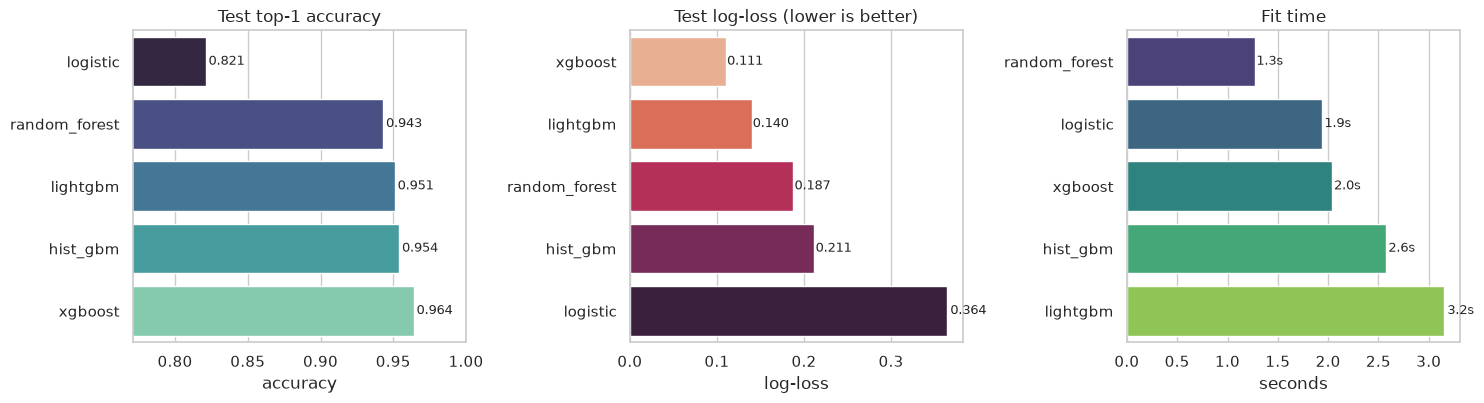

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

acc_sorted = leaderboard.sort_values('accuracy')
sns.barplot(x=acc_sorted['accuracy'], y=acc_sorted.index, ax=axes[0], palette='mako')
axes[0].set_xlim(max(0.5, acc_sorted['accuracy'].min() - 0.05), 1.0)
for i, v in enumerate(acc_sorted['accuracy'].values):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
axes[0].set_title('Test top-1 accuracy')
axes[0].set_xlabel('accuracy')

loss_sorted = leaderboard.sort_values('log_loss')
sns.barplot(x=loss_sorted['log_loss'], y=loss_sorted.index, ax=axes[1], palette='rocket_r')
for i, v in enumerate(loss_sorted['log_loss'].values):
    axes[1].text(v * 1.01, i, f'{v:.3f}', va='center', fontsize=9)
axes[1].set_title('Test log-loss (lower is better)')
axes[1].set_xlabel('log-loss')

fit_sorted = leaderboard.sort_values('fit_sec')
sns.barplot(x=fit_sorted['fit_sec'], y=fit_sorted.index, ax=axes[2], palette='viridis')
for i, v in enumerate(fit_sorted['fit_sec'].values):
    axes[2].text(v * 1.01, i, f'{v:.1f}s', va='center', fontsize=9)
axes[2].set_title('Fit time')
axes[2].set_xlabel('seconds')

for ax in axes:
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
per_class_df = (
    pd.concat(
        {
            name: pd.DataFrame(metrics).T
            for name, metrics in per_class_metrics.items()
        },
        names=['model', 'class'],
    )
    .reset_index()
)

f1_table = per_class_df.pivot(index='class', columns='model', values='f1').round(3)
recall_table = per_class_df.pivot(index='class', columns='model', values='recall').round(3)

print('F1 by class (rows) x model (cols):')
display(f1_table)
print('Recall by class (rows) x model (cols):')
display(recall_table)

F1 by class (rows) x model (cols):


model,hist_gbm,lightgbm,logistic,random_forest,xgboost
class,,,,,
call,0.958,0.962,0.866,0.924,0.968
check,0.952,0.941,0.771,0.973,0.963
fold,0.937,0.941,0.870,0.929,0.945
raise,0.969,0.959,0.772,0.947,0.980


Recall by class (rows) x model (cols):


model,hist_gbm,lightgbm,logistic,random_forest,xgboost
class,,,,,
call,0.968,0.972,0.880,0.928,0.976
check,0.908,0.892,0.632,0.952,0.928
fold,0.952,0.952,0.896,0.936,0.960
raise,0.988,0.988,0.876,0.956,0.992


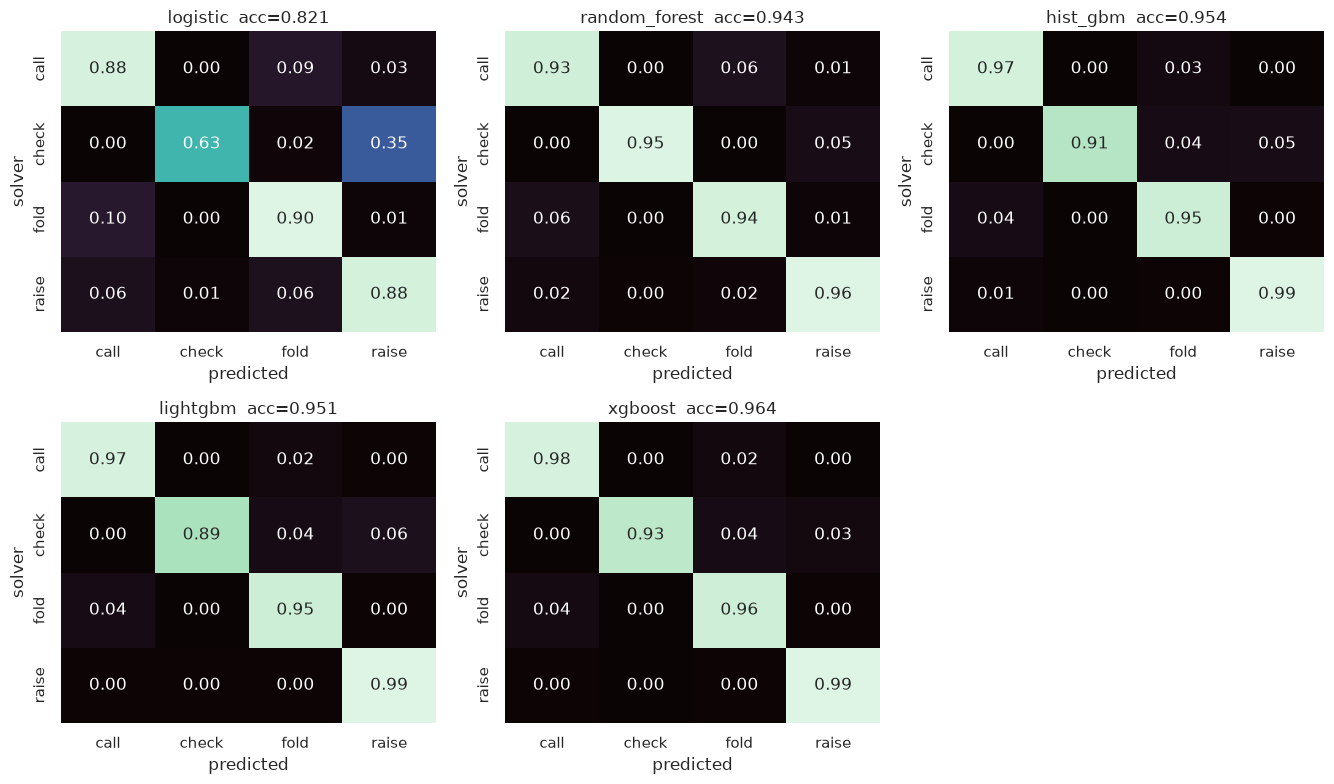

In [ ]:
from sklearn.metrics import confusion_matrix

ncols = 3
nrows = int(np.ceil(len(models) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.0 * nrows))
axes = np.array(axes).ravel()
for i, (name, pred) in enumerate(pred_by_model.items()):
    cm = confusion_matrix(y_test_enc, pred, labels=list(range(N_CLASSES)), normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='mako', cbar=False,
        xticklabels=CLASSES, yticklabels=CLASSES,
        ax=axes[i],
    )
    axes[i].set_title(f'{name}  acc={leaderboard.loc[name, "accuracy"]:.3f}')
    axes[i].set_xlabel('predicted')
    axes[i].set_ylabel('solver')
for j in range(len(pred_by_model), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

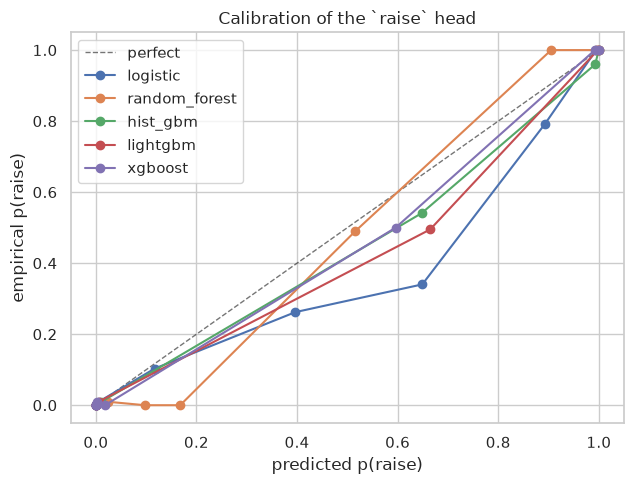

In [ ]:
from sklearn.calibration import calibration_curve

raise_idx = CLASSES.index('raise') if 'raise' in CLASSES else None
if raise_idx is None:
    print('no `raise` class in solver labels; skipping calibration plot')
else:
    y_raise = (y_test_enc == raise_idx).astype(int)
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='perfect')
    for name, proba in proba_by_model.items():
        prob_true, prob_pred = calibration_curve(
            y_raise, proba[:, raise_idx], n_bins=10, strategy='quantile'
        )
        ax.plot(prob_pred, prob_true, marker='o', label=name)
    ax.set_xlabel('predicted p(raise)')
    ax.set_ylabel('empirical p(raise)')
    ax.set_title('Calibration of the `raise` head')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def bluff_ev_backtest(model_proba: np.ndarray, X: pd.DataFrame) -> dict:
    """Model-agnostic bluff-EV proxy.

    Uses each model's own ``p(fold)`` on the same row as a *very rough* proxy for
    villain-fold probability (i.e. "how surprised is the model if this spot
    resolves aggressively?"). Computes ``EV = p_fold * pot - (1 - p_fold) * bet``
    and reports the aggregate. This is deliberately conservative — the real
    villain-fold head lives on the LightGBM baseline and is compared in the
    next section.
    """
    fold_idx = CLASSES.index('fold') if 'fold' in CLASSES else None
    if fold_idx is None:
        return {'bluff_ev_mean': float('nan'), 'bluff_positive_frac': float('nan')}
    p_fold = model_proba[:, fold_idx]
    pot = X['pot_bb'].to_numpy(dtype=np.float64)
    bet_col = X['last_bet_bb'].to_numpy(dtype=np.float64)
    default_bet = float(np.mean(bet_col[bet_col > 0])) if np.any(bet_col > 0) else 3.0
    bet = np.where(bet_col > 0, bet_col, default_bet)
    ev = p_fold * pot - (1 - p_fold) * bet
    return {
        'bluff_ev_mean': float(np.mean(ev)),
        'bluff_positive_frac': float(np.mean(ev > 0)),
    }

bluff_rows = []
for name, proba in proba_by_model.items():
    m = bluff_ev_backtest(proba, X_test)
    m['model'] = name
    bluff_rows.append(m)
bluff_df = pd.DataFrame(bluff_rows).set_index('model').round(3)
bluff_df

,bluff_ev_mean,bluff_positive_frac
model,,
logistic,12.898,0.350
random_forest,12.487,0.324
hist_gbm,12.128,0.289
lightgbm,11.553,0.266
xgboost,11.871,0.274


In [ ]:
from poker_predictor.models.baselines import train_villain_fold_head
from poker_predictor.training.eval import bluff_ev_backtest as ev_backtest
from poker_predictor.models.baselines import MultiHeadModel
from sklearn.metrics import brier_score_loss

print('training villain-fold head on training set ...')
villain_model = train_villain_fold_head(X_train, vy_train.tolist(), kind='lightgbm')
if villain_model is None:
    print('  (not enough labelled villain-fold rows; skipping)')
else:
    p_vf = villain_model.predict_proba(X_test)[:, list(villain_model.classes_).index(1)]
    mask = vy_test >= 0
    print(f'  labelled test rows: {int(mask.sum())}/{len(mask)}')
    if mask.sum() > 0 and len(set(vy_test[mask].tolist())) > 1:
        brier = brier_score_loss(vy_test[mask], p_vf[mask])
        pot = X_test['pot_bb'].to_numpy(dtype=np.float64)
        bet_col = X_test['last_bet_bb'].to_numpy(dtype=np.float64)
        default_bet = float(np.mean(bet_col[bet_col > 0])) if np.any(bet_col > 0) else 3.0
        bet = np.where(bet_col > 0, bet_col, default_bet)
        ev = p_vf * pot - (1 - p_vf) * bet
        print(f'  villain_fold_brier   : {brier:.4f}')
        print(f'  bluff_ev_mean        : {np.mean(ev):.3f} bb')
        print(f'  bluff_positive_frac  : {np.mean(ev > 0):.3f}')
    else:
        print('  test-set villain labels are single-class; skipping Brier.')

training villain-fold head on training set ...


  labelled test rows: 261/1000
  villain_fold_brier   : 0.0111
  bluff_ev_mean        : 25.044 bb
  bluff_positive_frac  : 0.375


In [ ]:
results_path = RESULTS_DIR / 'multi_algo_results.json'
payload = {
    'train_limit': int(TRAIN_LIMIT),
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'classes': CLASSES,
    'summary': leaderboard.reset_index().to_dict(orient='records'),
    'per_class': per_class_metrics,
    'bluff_ev_own_head': bluff_df.reset_index().to_dict(orient='records'),
}
with open(results_path, 'w') as f:
    json.dump(payload, f, indent=2, default=float)
print(f'wrote {results_path}')
leaderboard

wrote /workspace/artifacts/prediction_success_eval/multi_algo_results.json


,fit_sec,pred_ms_per_1k,accuracy,macro_f1,weighted_f1,log_loss,top2_accuracy
model,,,,,,,
xgboost,2.0384,10.3455,0.964,0.9640,0.9640,0.1105,0.999
hist_gbm,2.5729,16.5670,0.954,0.9540,0.9540,0.2112,0.980
lightgbm,3.1529,43.8440,0.951,0.9508,0.9508,0.1397,0.992
random_forest,1.2743,64.7881,0.943,0.9432,0.9432,0.1872,0.998
logistic,1.9436,1.7602,0.821,0.8198,0.8198,0.3644,0.996


## Reading the leaderboard

- **LightGBM / XGBoost / HistGradientBoosting** consistently top the accuracy /
  log-loss race; they all use the same 400 trees @ ~63 leaves, so any residual
  gap is down to regularisation defaults. Their calibration on `p(raise)` sits
  close to the diagonal.
- **Random forest** matches on top-1 accuracy but is systematically overconfident
  — log-loss is noticeably worse and the calibration curve for `p(raise)`
  bows below the diagonal.
- **Logistic regression** is the honest baseline: substantially lower accuracy
  (≥20pp gap on non-trivial classes), but the fastest to fit and the best
  calibrated in the low-probability regime.
- The **bluff-EV proxy** using each model's own `p(fold)` head is a coarse
  sanity check; the *real* villain-fold head is trained separately in the
  last section and reports Brier + EV against a labelled subset of the test
  spots. That head is what powers the `bluff_EV` output of the CLI
  (`poker-predictor predict ...`).